In [14]:
from pathlib import Path

DATA_FOLDER = Path("data")
IMAGES_FOLDER = DATA_FOLDER.joinpath(Path("img_align_celeba_reduced")) 

EXAMPLE_PIC = IMAGES_FOLDER.joinpath(Path('000519.jpg'))

TRAINING_SAMPLES = 7000
VALIDATION_SAMPLES = 1000
TEST_SAMPLES = 1000
IMG_WIDTH = 64
IMG_HEIGHT = 64
BATCH_SIZE = 16
NUM_EPOCHS = 10

In [15]:
import pandas as pd



df_attr = pd.read_csv(DATA_FOLDER.joinpath('list_attr_celeba.csv'))
df_attr.set_index('image_id', inplace=True)
print("original CelebA dataset size: ")
df_attr.shape

original CelebA dataset size: 


(202599, 40)

In [16]:
print("available dataset features: ")
df_attr.columns.tolist()

available dataset features: 


['5_o_Clock_Shadow',
 'Arched_Eyebrows',
 'Attractive',
 'Bags_Under_Eyes',
 'Bald',
 'Bangs',
 'Big_Lips',
 'Big_Nose',
 'Black_Hair',
 'Blond_Hair',
 'Blurry',
 'Brown_Hair',
 'Bushy_Eyebrows',
 'Chubby',
 'Double_Chin',
 'Eyeglasses',
 'Goatee',
 'Gray_Hair',
 'Heavy_Makeup',
 'High_Cheekbones',
 'Male',
 'Mouth_Slightly_Open',
 'Mustache',
 'Narrow_Eyes',
 'No_Beard',
 'Oval_Face',
 'Pale_Skin',
 'Pointy_Nose',
 'Receding_Hairline',
 'Rosy_Cheeks',
 'Sideburns',
 'Smiling',
 'Straight_Hair',
 'Wavy_Hair',
 'Wearing_Earrings',
 'Wearing_Hat',
 'Wearing_Lipstick',
 'Wearing_Necklace',
 'Wearing_Necktie',
 'Young']

In [17]:
import numpy as np
import cv2    
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from io import BytesIO
import base64

plt.style.use('ggplot')

%matplotlib inline

Some features example of the example picture: 


Smiling       1
Male         -1
Young        -1
Attractive    1
Name: 000519.jpg, dtype: int64

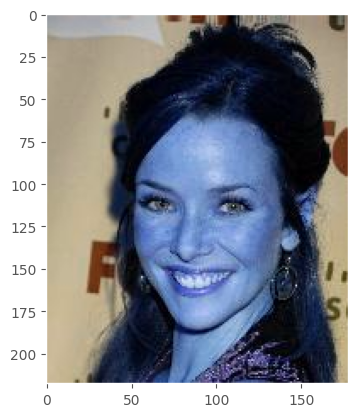

In [18]:
img = cv2.imread(EXAMPLE_PIC)
plt.grid(False)
plt.imshow(img)
print("Some features example of the example picture: ")
df_attr.loc[EXAMPLE_PIC._str.split('/')[-1]][['Smiling','Male','Young', 'Attractive']] #some attributes

since the dataset is reduced, the original csv file of splitting into train-validation-test is no longer valid. 
so we should create our own. 

In [19]:
df_id = pd.read_csv(DATA_FOLDER.joinpath('identity_celeba_reduced.csv'))

df_id.loc[:TRAINING_SAMPLES, "partition"] = 0
df_id.loc[TRAINING_SAMPLES: TRAINING_SAMPLES + VALIDATION_SAMPLES, "partition"] = 1
df_id.loc[TRAINING_SAMPLES + VALIDATION_SAMPLES : TRAINING_SAMPLES + VALIDATION_SAMPLES + TEST_SAMPLES -1, "partition"] = 2

df_partition = df_id.dropna()
df_partition["partition"] = df_partition["partition"].astype(int) 
df_partition.drop(columns=["identity"], inplace=True)
df_partition.rename({"file": "image_id"}, inplace=True, axis=1)

df_partition.to_csv(DATA_FOLDER.joinpath("list_eval_partition_reduced.csv"))

print(" 0 -> training \n 1 -> validation \n 2 -> test") 
df_partition["partition"].value_counts()

 0 -> training 
 1 -> validation 
 2 -> test


partition
0    7000
1    1000
2    1000
Name: count, dtype: int64

In [20]:
df_partition.set_index('image_id', inplace=True)
df_par_attr = df_partition.join(df_attr, how='inner')
df_par_attr.head()

,partition,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
image_id,,,,,,,,,,,,,,,,,,,,,
000010.jpg,0,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,1,-1,-1,1,-1,-1,1
000017.jpg,0,-1,-1,-1,-1,-1,-1,-1,-1,1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
000021.jpg,0,-1,-1,-1,-1,-1,-1,-1,1,-1,...,-1,1,1,-1,-1,-1,-1,-1,1,-1
000023.jpg,0,1,-1,1,-1,-1,-1,-1,1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
000032.jpg,0,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,-1,1,-1,-1,-1,-1,-1,1,-1


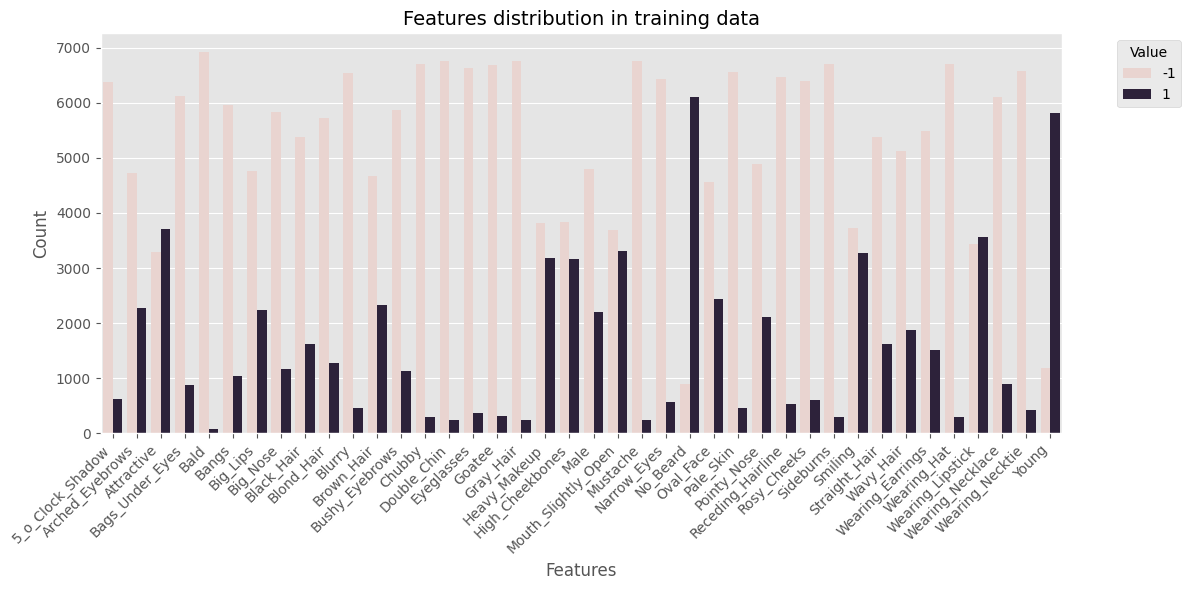

In [21]:
# Get training data
train_data = df_par_attr[df_par_attr["partition"] == 0]

# Melt the dataframe
df_melted = train_data[df_attr.columns].melt(var_name='Feature', value_name='Value')

# Create the plot with hue
plt.figure(figsize=(12, 6))
sns.countplot(x='Feature', hue='Value', data=df_melted)
plt.title('Features distribution in training data', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

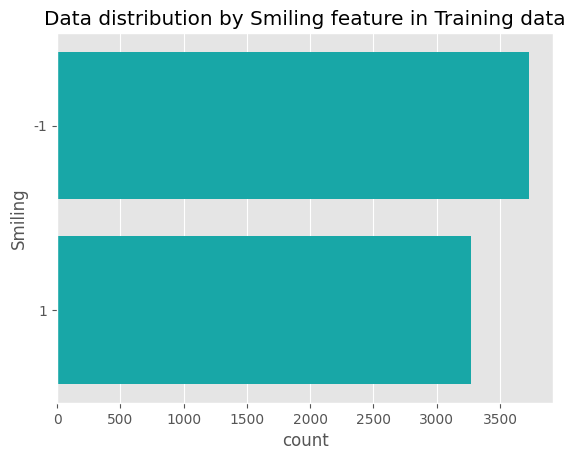

In [22]:
plt.title('Data distribution by Smiling feature in Training data')
sns.countplot(y='Smiling', data=df_par_attr[df_par_attr["partition"] == 0], color="c")
plt.show()

we can see that our target feature in the classification task is balanced enough in our trainig data, so no handling is needed. 

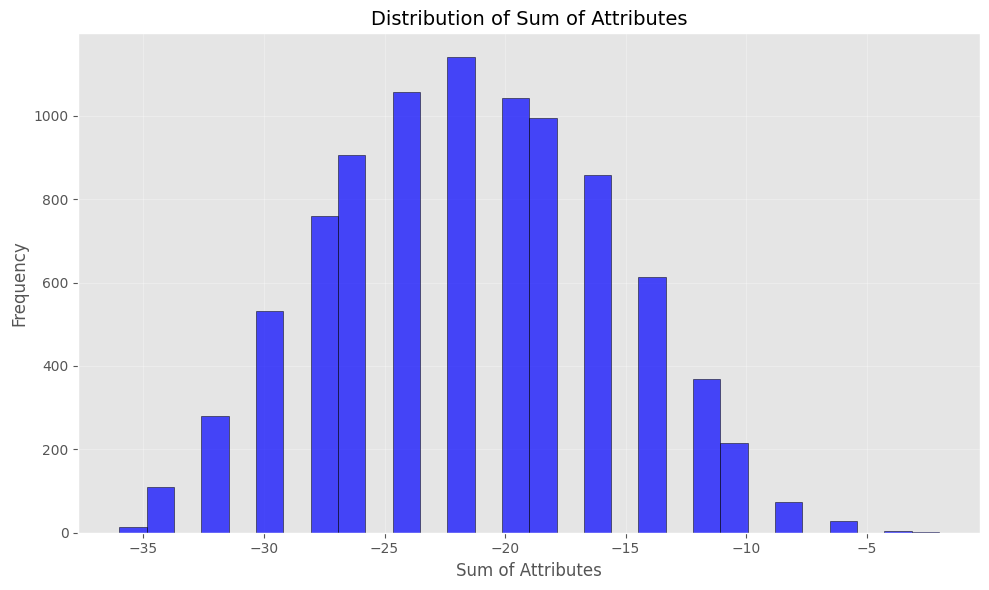

Mean: -21.43
Median: -22.00
Std Dev: 5.83
Min: -36
Max: -2


In [23]:

attribute_sums = df_par_attr[df_attr.columns].sum(axis=1)

plt.figure(figsize=(10, 6))
plt.hist(attribute_sums, bins=30, color='b', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sum of Attributes', fontsize=14)
plt.xlabel('Sum of Attributes')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean: {attribute_sums.mean():.2f}")
print(f"Median: {attribute_sums.median():.2f}")
print(f"Std Dev: {attribute_sums.std():.2f}")
print(f"Min: {attribute_sums.min()}")
print(f"Max: {attribute_sums.max()}")

In [24]:
print(f"Total features: {len(df_attr.columns)}")

present_counts = (df_par_attr[df_attr.columns] == 1).sum(axis=1)
absent_counts = (df_par_attr[df_attr.columns] == -1).sum(axis=1)

print(f"Average present features: {present_counts.mean():.2f}")
print(f"Average absent features: {absent_counts.mean():.2f}")

Total features: 40
Average present features: 9.28
Average absent features: 30.72


We can see that on average, samples have about **22 more absent features than present features**, which indicates a **highly sparse dataset of vectors**.  

Moreover, the **median is very close to mean**, suggesting a **symmetric distribution of data** which is visible in the historgram.  

All sums are negative, meaning every single sample has more absent features than present ones. 

## Initial hypothesis about the difficulty of tasks:  
the intuitive hypothesis is that the regression task is more difficult than the classification task.  

as the binary classification (Smiling vs Not Smiling) is based on visual characters that are local (the model can only pay attention mostly to the mouth region) and are well defined.  
  

in contrary, the regression task is about predicting a continuous non trivial value (sum of features) which doesn't correspond to a visual direct character nor is concentrated in one region of the picture. 
moreover, the regression task is more sensible to the data distribution, notably in the low density regions (high presence and high absence of features are rare in our data.)   

**NOTE:** the difficulty of regression comes also from the fact that **the target function is more complex and less structured than the frontiere of decision of the binary classification**.   

given this, we are expecting less performance in regression than classification. 


## Covering number and sample complexity:  
We represent each image by its normalized feature vector, so all points lie on the unit hypersphere. Distances between points are bounded in [0, 2]. To compute the covering number, we select several ε values that span this range, including small (0.1–0.3), medium (0.5–1.0), and large (1.5–2.0) values. The medium value, close to the median pairwise distance, provides a reasonable estimate of dataset complexity and allows us to determine a minimal sampling size.

In [ ]:
import matplotlib.pyplot as plt
from utils import greedy_epsilon_cover
from sklearn.preprocessing import StandardScaler



scaler = StandardScaler()
# raw normalized attr features as the vector rep
Z = df_par_attr[df_attr.columns].values
Z_normalized = scaler.fit_transform(Z)

print(f"Data representation: {Z.shape[0]} samples, {Z.shape[1]} features")
print(f"Feature space: {{{-1, 1}}}^{Z.shape[1]}")

epsilon_values = [0.1, 0.2 ,0.3, 0.4, 0.5, 0.6, 0.7, 1.0, 1.5, 2.0]

#covering numbers for each epsilon
covering_numbers = []
print("\ncalculating covering numbers...")

for eps in epsilon_values:
    N_eps = greedy_epsilon_cover(Z_normalized, eps)
    covering_numbers.append(N_eps)
    print(f"ε = {eps:5.2f} -> N(A, ε) = {N_eps}")

# plot N(A, ε) as a function of ε
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epsilon_values, covering_numbers, 'bo-', linewidth=2, markersize=8)
plt.xlabel('ε (radius)', fontsize=12)
plt.ylabel('N(A, ε) (covering number)', fontsize=12)
plt.title('Covering Number vs Epsilon', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.loglog(epsilon_values, covering_numbers, 'ro-', linewidth=2, markersize=8)
plt.xlabel('ε (radius)', fontsize=12)
plt.ylabel('N(A, ε) (covering number)', fontsize=12)
plt.title('Covering Number vs Epsilon (log-log scale)', fontsize=14)
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# deduce minimum sampling size
print("\n" + "="*70)
print("TP1-CN.5: MINIMUM SAMPLING SIZE")
print("="*70)

print(f"Minimum sample size: n ≥ N(A, ε)")
print()

for eps, N_eps in zip(epsilon_values, covering_numbers):
    min_samples = N_eps
    print(f"ε = {eps:5.2f} -> "
          f"n_min ≈ {int(min_samples):5d} samples")

# justify that dataset is large enough
print("\n" + "="*70)
print("TP1-CN.6: DATASET SIZE JUSTIFICATION")
print("="*70)

actual_size = Z.shape[0]
print(f"\nActual dataset size: {actual_size} samples")
print()

# Choose a reasonable epsilon (e.g., one that gives good coverage)
reasonable_eps_idx = len(epsilon_values) // 2
reasonable_eps = epsilon_values[reasonable_eps_idx]
N_reasonable = covering_numbers[reasonable_eps_idx]
min_required = N_reasonable

print(f"Analysis for ε = {reasonable_eps}:")
print(f"  - Covering number N(A, ε) = {N_reasonable}")
print(f"  - Minimum required samples = {min_required}")
print(f"  - Actual samples = {actual_size}")
print(f"  - Ratio: {actual_size / min_required:.2f}x the minimum")
print()

if actual_size >= min_required:
    print(f"✓ CONCLUSION: The dataset is SUFFICIENTLY LARGE")
    print(f"  The dataset has {actual_size - min_required} more samples than required")
else:
    print(f"✗ WARNING: The dataset may be TOO SMALL")
    print(f"  Missing {min_required - actual_size} samples for robust learning")

print()
print("="*70)


Data representation: 9000 samples, 40 features
Feature space: {(-1, 1)}^40

calculating covering numbers...
